In [7]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import OrdinalEncoder,StandardScaler,TargetEncoder,FunctionTransformer
from sklearn.metrics import classification_report,confusion_matrix,roc_curve,roc_auc_score

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import sys
import os

# Add the parent directory (project root) to the Python path
sys.path.append(os.path.abspath('..'))

In [8]:
df = pd.read_csv('telco-churn-dataset.csv') # Load the dataset

In [9]:
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## Necessary Preprocessing 

In [10]:
# Convert TotalCharges to numeric
df = df[df['TotalCharges'] != ' ']
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='raise')

# Also convert SeniorCitizen column to numeric
df['SeniorCitizen'] = pd.to_numeric(df['SeniorCitizen'],errors='raise')

# Map gender before hand to avoid data leakage and jargaon
# df['gender'] = df['gender'].map({'Male':1,"Female":0})


# Lets seperate columns into group so we can proceed easily
# Dropped churn as it will be handled seprately and gender need's a different mapping
# Also SeniorCitizen is numeric

drop_cols = ['MonthlyCharges','TotalCharges','customerID']
target_encoding_cols = ['InternetService','PaymentMethod']
ordinal_cols = ['Contract']


In [11]:
X , y = df.drop(columns=['Churn']),df['Churn'].map( lambda x : 1 if x == 'Yes' else 0)

# We seperate the columns after seperating to avoid data leak
# The rest of the cols are just to be mapped 
service_columns = [
    x for x in X.columns 
    if x not in target_encoding_cols + ordinal_cols + drop_cols + [ 'SeniorCitizen', 'tenure']
]

X_train , X_test , y_train , y_test = train_test_split(
                                                            X,y,
                                                            test_size = 0.2,
                                                            stratify=y,
                                                            random_state = 42
)


In [12]:
# Make sure to pass the slice itself cause if otherwise there could be data leaks in case we try to pass the original dataframe.
from src.binary_map import to_binary_map

 # Also wrtting our map function inside the FunctionTransformer
binary_transformer = FunctionTransformer(
    to_binary_map,
    feature_names_out='one-to-one'  # tells sklearn: output names = input names
)

## Building the Pipeline

In [13]:
preprocessor = ColumnTransformer(
                                    transformers = [
                                                        ('binary_encoder',binary_transformer,service_columns),
                                                        ('ordinal_encoder',OrdinalEncoder(),ordinal_cols),
                                                        ('target_encoder',TargetEncoder(smooth=10.0),target_encoding_cols),
                                                        ('drop_columns','drop',drop_cols)
                                    ],
                            remainder = 'passthrough'
)

In [14]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(max_depth=6, class_weight='balanced', random_state=42))
])

rf_pipeline.fit(X_train, y_train)
print(f"Random Forest Train Score: {rf_pipeline.score(X_train, y_train):.4f}")
print(f"Random Forest Test Score: {rf_pipeline.score(X_test, y_test):.4f}")

Random Forest Train Score: 0.7596
Random Forest Test Score: 0.7221


In [15]:
# The pipelining was successfully , actually I dont know how so I isolated the features , map , variables and pipeline as much as I can to create a leak free pipeline
# Now finetuning and model evaluation

In [16]:
# Let's for now check the model performance on the XGBoostClassifier

In [17]:
# Deep clone the preprocessor to prevent parameter overwriting
xgb_preprocessor = clone(preprocessor)

xgb_pipeline = Pipeline([
    ('preprocessor', xgb_preprocessor),
    ('classifier', XGBClassifier(
        max_depth=4,              # Slightly shallower depth prevents boosting overfits
        learning_rate=0.05,       # Slow learning rate allows trees to correct errors smoothly
        n_estimators=150,         # Total sequential boosting rounds
        scale_pos_weight=2.7,     # Forces gradient updates to balance minority Churn rows
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train)
print(f"XGBoost Train Score: {xgb_pipeline.score(X_train, y_train):.4f}")
print(f"XGBoost Test Score: {xgb_pipeline.score(X_test, y_test):.4f}")


XGBoost Train Score: 0.7714
XGBoost Test Score: 0.7342


In [18]:
# 1. Clean clone of your unified preprocessor layout
xgb_preprocessor_search = clone(preprocessor)

# 2. Rebuild the core base pipeline structure
search_pipeline = Pipeline([
    ('preprocessor', xgb_preprocessor_search),
    ('classifier', XGBClassifier(random_state=42, scale_pos_weight=2.7)) # Balance anchor remains fixed
])

# 3. Define the search space using the 'stepname__parameter' syntax
# This tells scikit-learn to map these directly to the 'classifier' step.
param_distributions = {
    'classifier__max_depth': [3, 4, 5, 6, 7],                      # Limits depth to prevent overfitting
    'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15], # Controls boosting step size
    'classifier__n_estimators': [100, 150, 200, 250],           # Number of sequential trees
    'classifier__subsample': [0.6, 0.7, 0.8, 0.9],              # Row subsampling percentage per tree
    'classifier__colsample_bytree': [0.6, 0.7, 0.8, 0.9],       # Feature subsampling percentage per tree
    'classifier__min_child_weight': [1, 3, 5, 7]                # Higher values force conservative splits
}

# 4. Initialize the randomized search manager
# n_iter=20 means it randomly samples 20 distinct parameter combinations to test
xgb_random_search = RandomizedSearchCV(
    estimator=search_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='roc_auc',          # Optimizes for Area Under the Curve (best for imbalanced churn data)
    cv=5,                       # 5-Fold Stratified Cross-Validation
    random_state=42,
    n_jobs=-1,                  # Uses all available computer CPU cores to run splits in parallel
    verbose=1
)

# 5. Fit the search space safely on your training split
print("Starting Hyperparameter Tuning...")
xgb_random_search.fit(X_train, y_train)

# 6. Extract the best performance metrics
print("\n--- Tuning Optimization Complete ---")
print(f"Best Cross-Validation AUC: {xgb_random_search.best_score_:.4f}")
print("Best Hyperparameters Found:")
for param, val in xgb_random_search.best_params_.items():
    print(f"  {param}: {val}")


Starting Hyperparameter Tuning...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

--- Tuning Optimization Complete ---
Best Cross-Validation AUC: 0.8493
Best Hyperparameters Found:
  classifier__subsample: 0.6
  classifier__n_estimators: 150
  classifier__min_child_weight: 7
  classifier__max_depth: 6
  classifier__learning_rate: 0.01
  classifier__colsample_bytree: 0.8


In [19]:
# Extract the optimal tuned pipeline configuration
best_xgb_model = xgb_random_search.best_estimator_

# Check the true generalization score on your test split
print("--- Optimized Tuned XGBoost Performance ---")
print(f"Tuned XGBoost Train Score: {best_xgb_model.score(X_train, y_train):.4f}")
print(f"Tuned XGBoost Test Score:  {best_xgb_model.score(X_test, y_test):.4f}")


--- Optimized Tuned XGBoost Performance ---
Tuned XGBoost Train Score: 0.7815
Tuned XGBoost Test Score:  0.7456


In [20]:
# Result 1 : 
''' 
Best Cross-Validation AUC: 0.8482
Best Hyperparameters Found:
  classifier__subsample: 0.8
  classifier__n_estimators: 200
  classifier__min_child_weight: 5
  classifier__max_depth: 4
  classifier__learning_rate: 0.03
  classifier__colsample_bytree: 0.9

--- Optimized Tuned XGBoost Performance ---
Tuned XGBoost Train Score: 0.7712
Tuned XGBoost Test Score:  0.7356

Classification report : 
precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.81      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407

Confusion Matrix
[[732 301]
 [ 71 303]]
'''

' \nBest Cross-Validation AUC: 0.8482\nBest Hyperparameters Found:\n  classifier__subsample: 0.8\n  classifier__n_estimators: 200\n  classifier__min_child_weight: 5\n  classifier__max_depth: 4\n  classifier__learning_rate: 0.03\n  classifier__colsample_bytree: 0.9\n\n--- Optimized Tuned XGBoost Performance ---\nTuned XGBoost Train Score: 0.7712\nTuned XGBoost Test Score:  0.7356\n\nClassification report : \nprecision    recall  f1-score   support\n\n           0       0.91      0.71      0.80      1033\n           1       0.50      0.81      0.62       374\n\n    accuracy                           0.74      1407\n   macro avg       0.71      0.76      0.71      1407\nweighted avg       0.80      0.74      0.75      1407\n\nConfusion Matrix\n[[732 301]\n [ 71 303]]\n'

In [21]:
# Now Eval: 
y_pred = best_xgb_model.predict(X_test)
y_pred_proba = best_xgb_model.predict_proba(X_test)[:, 1]

In [22]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1033
           1       0.51      0.80      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



In [23]:
print(confusion_matrix(y_test,y_pred))
# plt.figure(figsize=(15,7))
# sns.heatmap(
#                 data = confusion_matrix(y_test,y_pred),
#                 cmap = 'inferno',
#                 annot = True,
#                 fmt = '.2f'
# )
# plt.title('Confusion matrix ')
# plt.tight_layout()
# plt.show()


[[749 284]
 [ 74 300]]


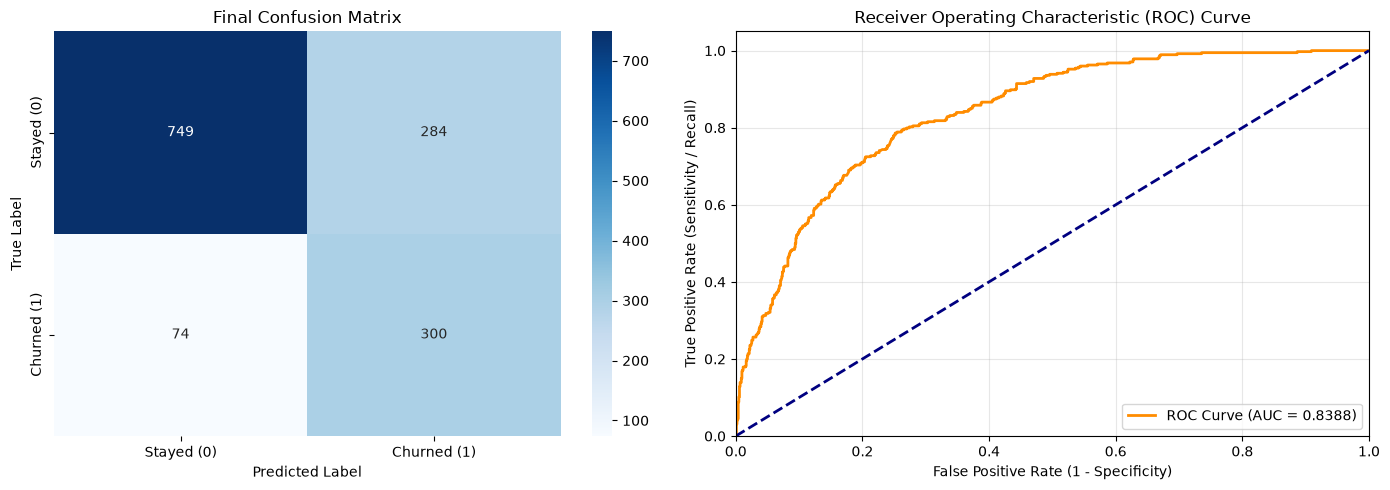

In [24]:
#  Set up the plotting canvas for the evaluation visuals
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot A: The Confusion Matrix Heatmap ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], 
            xticklabels=['Stayed (0)', 'Churned (1)'], 
            yticklabels=['Stayed (0)', 'Churned (1)'])
ax[0].set_title('Final Confusion Matrix')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

# --- Plot B: The ROC-AUC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Baseline random guessing line
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate (1 - Specificity)')
ax[1].set_ylabel('True Positive Rate (Sensitivity / Recall)')
ax[1].set_title('Receiver Operating Characteristic (ROC) Curve')
ax[1].legend(loc="lower right")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
remainder_cols = ['SeniorCitizen', 'tenure']

# Combine them sequentially to match the preprocessor output array structure
ordered_feature_names = service_columns + ordinal_cols + target_encoding_cols + remainder_cols

importances = best_xgb_model.named_steps['classifier'].feature_importances_

# 3. Create a clean, sorted DataFrame
xgb_importance_df = pd.DataFrame({
    'Feature': ordered_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("==================================================")
print("     TOP 10 MOST IMPORTANT FEATURES (XGBOOST)     ")
print("==================================================")
print(xgb_importance_df.head(10).to_string(index=False))


     TOP 10 MOST IMPORTANT FEATURES (XGBOOST)     
         Feature  Importance
        Contract    0.602364
 InternetService    0.059121
          tenure    0.047182
 StreamingMovies    0.031250
    PhoneService    0.030465
  OnlineSecurity    0.027246
     StreamingTV    0.025921
   PaymentMethod    0.022410
     TechSupport    0.021392
PaperlessBilling    0.021043


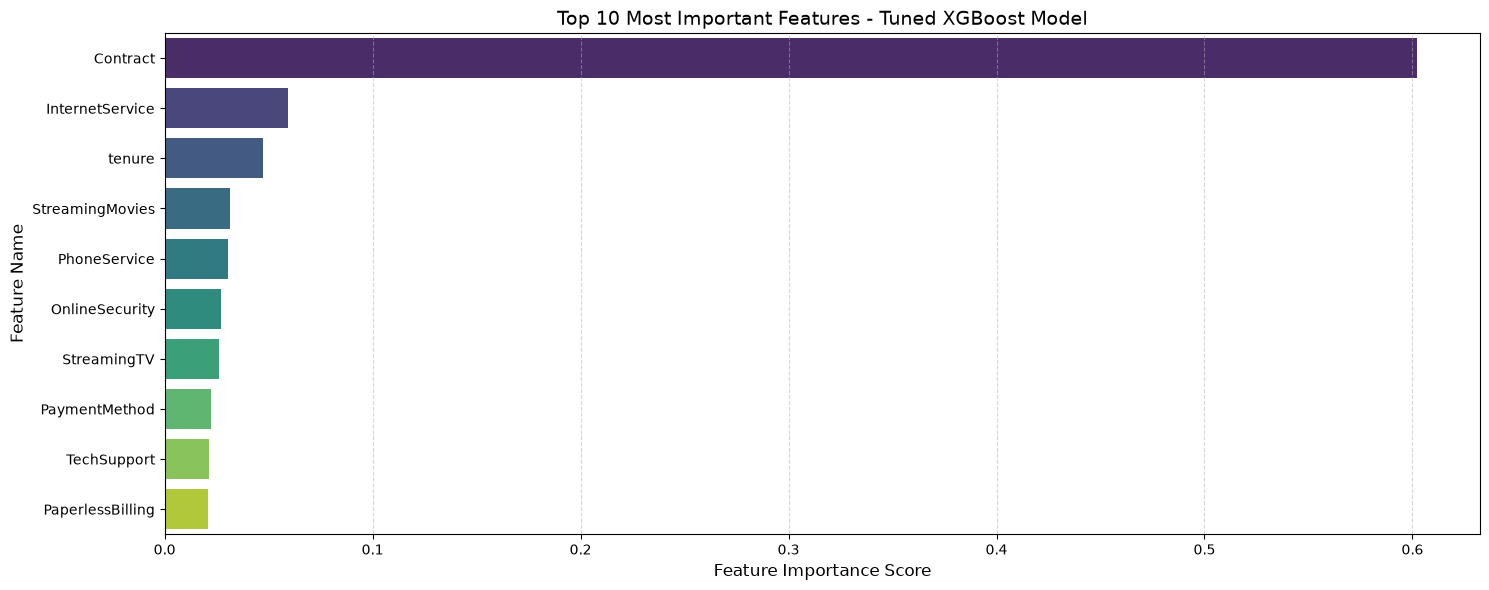

In [26]:
plt.figure(figsize=(15, 6))

# Plot the top 10 features using a horizontal barplot
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=xgb_importance_df.head(10), 
    palette='viridis',
    hue='Feature', 
    legend=False
)


plt.title('Top 10 Most Important Features - Tuned XGBoost Model', fontsize=14)
plt.xlabel('Feature Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()


In [30]:
# Saving our best model via joblib
import joblib
import os

BASE_DIR = os.path.dirname(os.getcwd())
PATH = os.path.join(BASE_DIR, 'models', 'xgboost_model.joblib')
joblib.dump(best_xgb_model, PATH)

['c:\\Users\\hp\\Desktop\\xgbc-customer-churn\\models\\xgboost_model.joblib']